<a href="https://colab.research.google.com/github/Harshithpalan/Python-projects/blob/main/system%20for%20credit%20card%20transactions%20using%20autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Anomaly Detection using Autoencoders

Autoencoders are neural networks trained to reconstruct their input. For anomaly detection, we train the model only on 'normal' data. When presented with an anomaly, the model will struggle to reconstruct it, resulting in a high reconstruction error (Mean Squared Error).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# 1. Simulate Dataset
# 5000 normal transactions, 50 anomalies
np.random.seed(42)
normal_data = np.random.normal(loc=0, scale=1, size=(5000, 20))
anomaly_data = np.random.normal(loc=4, scale=2, size=(50, 20))

# Create DataFrame
df_normal = pd.DataFrame(normal_data)
df_normal['label'] = 0
df_anomaly = pd.DataFrame(anomaly_data)
df_anomaly['label'] = 1

df = pd.concat([df_normal, df_anomaly]).sample(frac=1).reset_index(drop=True)
display(df.head())

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,label
0,0.269714,-0.638608,0.735529,-0.131882,0.838375,0.067303,0.500047,-0.442721,-0.710025,-0.284429,...,2.524102,1.260144,1.519977,-0.104638,-0.536781,-2.203706,-0.598091,-1.379487,0.768624,0
1,2.054194,0.147821,-1.416269,-0.642776,-0.458877,-1.017585,0.860183,0.810260,-1.155452,0.725081,...,1.902558,2.865212,-0.901993,2.824220,-0.354206,-0.592465,0.327072,-0.582061,0.399044,0
2,-0.151319,1.217386,-0.314030,0.079566,-0.234805,-1.750059,-0.804148,1.567365,-0.863933,0.794170,...,-0.404801,0.427247,-0.058584,0.369907,-2.495424,-1.030056,-0.631059,-1.018773,-0.128196,0
3,-0.112914,-0.433946,0.905190,-0.086795,0.000887,0.899874,2.190736,-0.444462,-0.876240,-0.989059,...,-1.090519,-0.373222,-0.285280,1.556399,1.192860,-1.536715,1.584824,-1.216151,0.160291,0
4,1.832235,0.101455,-1.037027,-1.022276,1.991010,2.463909,0.336637,-0.613895,0.332582,-0.305628,...,0.350088,-0.032448,-0.084386,-0.220104,0.948545,-0.192786,2.055566,2.148782,-0.378265,0


In [2]:
# 2. Preprocessing
# Autoencoders for anomaly detection are trained ONLY on normal data
X = df.drop('label', axis=1).values
y = df['label'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Filter for normal instances for training
X_train_normal = X_train[y_train == 0]
print(f"Training on {len(X_train_normal)} normal samples.")

Training on 3996 normal samples.


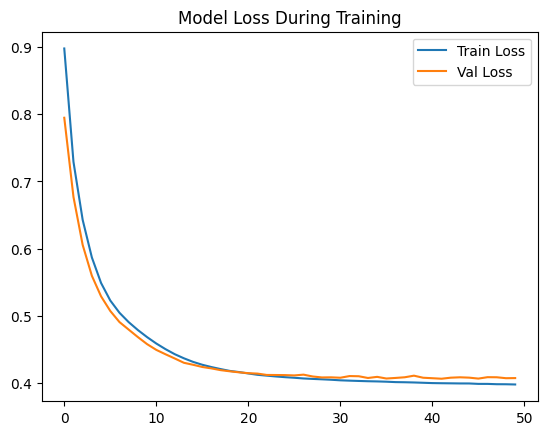

In [3]:
# 3. Build Autoencoder Model
input_dim = X_train_normal.shape[1]
encoding_dim = 10 # Compressed representation

input_layer = Input(shape=(input_dim,))
# Encoder
encoded = Dense(encoding_dim, activation='relu')(input_layer)
# Decoder
decoded = Dense(input_dim, activation='linear')(encoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss During Training')
plt.legend()
plt.show()

In [4]:
# 4. Detect Anomalies
# Calculate Reconstruction Error (MSE)
predictions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - predictions, 2), axis=1)

# Define threshold (e.g., 95th percentile of normal training error)
train_predictions = autoencoder.predict(X_train_normal)
train_mse = np.mean(np.power(X_train_normal - train_predictions, 2), axis=1)
threshold = np.percentile(train_mse, 95)

# Classify
y_pred = [1 if e > threshold else 0 for e in mse]

from sklearn.metrics import classification_report, confusion_matrix
print("Threshold Selected:", threshold)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Threshold Selected: 0.7335488105551253

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1004
           1       0.08      1.00      0.15         6

    accuracy                           0.93      1010
   macro avg       0.54      0.97      0.56      1010
weighted avg       0.99      0.93      0.96      1010

